## Relatório PDI - Limiarização
## Lab 6

**Aluno(s):** Gabriella Rodrigues, Nayara Amaral, Veronica Isobe \
**Data de publicação:** 03/04/2026 \
**Data de realização dos experimentos:** 30/03/2026

# 1. Introdução

# 2. Procedimentos experimentais

### 2.1 Operações de limiarização manual, e limiarização adaptativa de Otsu

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [31]:
img = cv2.imread('foto1.jpg')
rice = cv2.imread('rice.png')
postura = cv2.imread('postura_incorreta.jpg')
img2 = cv2.imread("aula04fig02.png")
img_gray = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
rice_gray = cv2.cvtColor(rice, cv2.COLOR_RGBA2GRAY)
postura_gray = cv2.cvtColor(postura, cv2.COLOR_RGBA2GRAY)

### Limiarização Manual

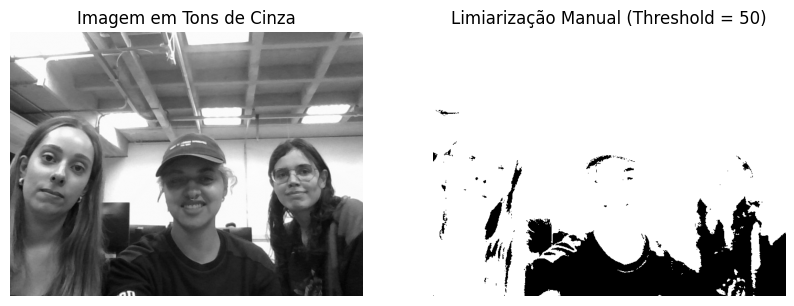

In [5]:
limiar = 50
_, img_manual_thresh = cv2.threshold(img_gray, limiar, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagem em Tons de Cinza')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_manual_thresh, cmap='gray')
plt.title(f'Limiarização Manual (Threshold = {limiar})')
plt.axis('off')

plt.show()

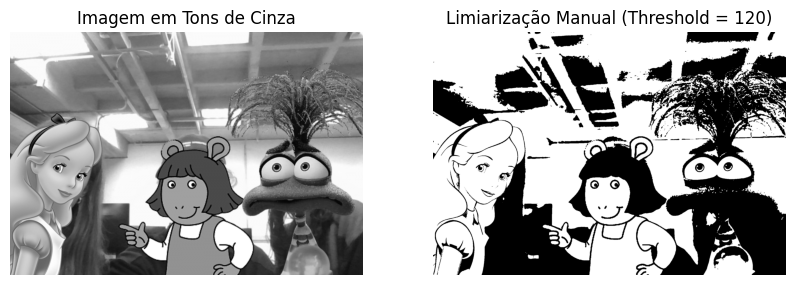

In [7]:
# imagem personagens

img_avatar = cv2.imread('foto_personagens.png')
img_gray_avatar = cv2.cvtColor(img_avatar, cv2.COLOR_RGBA2GRAY)

limiar = 120
_, img_manual_thresh_avatar = cv2.threshold(img_gray_avatar, limiar, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray_avatar, cmap='gray')
plt.title('Imagem em Tons de Cinza')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_manual_thresh_avatar, cmap='gray')
plt.title(f'Limiarização Manual (Threshold = {limiar})')
plt.axis('off')

plt.show()

### Limiarização Adaptativa de Otsu

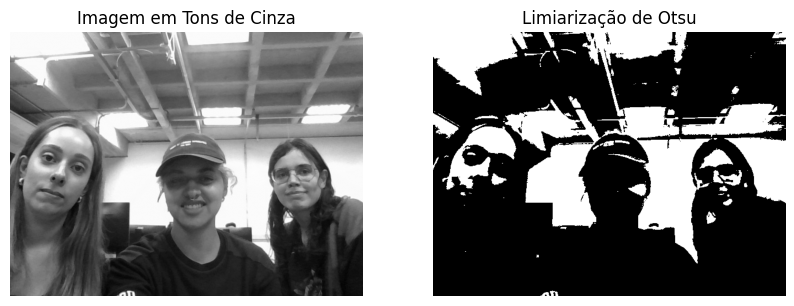

In [10]:
_, img_otsu_thresh = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagem em Tons de Cinza')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_otsu_thresh, cmap='gray')
plt.title('Limiarização de Otsu')
plt.axis('off')

plt.show()

3b

In [19]:
filterChoice = 1
limiar = 80

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Erro ao acessar webcam")
    exit()

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = None
gravando = False
        
contador = 0
while True:
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    if not ret:
        break
    filterName = ''
    frameWithFilter = None
    if filterChoice == 1:
        t, frameWithFilter = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        texto = f"Otsu (T={int(t)})"
    else:
        _, frameWithFilter = cv2.threshold(gray, limiar, 255, cv2.THRESH_BINARY)
        texto = f"Manual (T={int(limiar)})"

        
    key = cv2.waitKey(1) & 0xFF
        
    if key == ord('s'):
        if filterChoice == 1:
            filterChoice = 2
        else:
            filterChoice = 1
    thresh_bgr = cv2.cvtColor(frameWithFilter, cv2.COLOR_GRAY2BGR)

    combinado = np.hstack((frame, thresh_bgr))
    cv2.putText(combinado, texto, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
    cv2.putText(combinado, "Pressione: s=trocar | w=gravar | +/- limiar | q=sair",
                (10, 460), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)

    cv2.imshow("Original | Limiarizada", combinado)

    if gravando:
        out.write(combinado)

    if key == ord('+'):
        limiar = min(255, limiar + 5)

    if key == ord('-'):
        limiar = max(0, limiar - 5)

    if key == ord('w'):
        gravando = not gravando

        if gravando:
            print("Gravando...")
            out = cv2.VideoWriter(
                "video_demo.avi",
                fourcc,
                20.0,
                (combinado.shape[1], combinado.shape[0])
            )
        else:
            print("Parou gravação")
            out.release()   
    if key == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

Gravando...
Parou gravação


4 No contexto da aplicação do nosso trabalho final da diciplina, a limiarização ajuda a limitar o que seria a pessoa (objeto de estudo onde será feito a análise de postura), do fundo. Abaixo um exemplo com imagens que estamos utilizando.

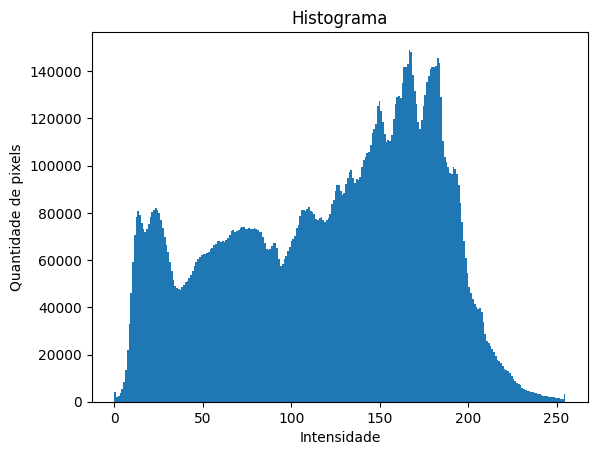

In [32]:
plt.hist(postura.ravel(), bins=256)
plt.title("Histograma")
plt.xlabel("Intensidade")
plt.ylabel("Quantidade de pixels")
plt.show()

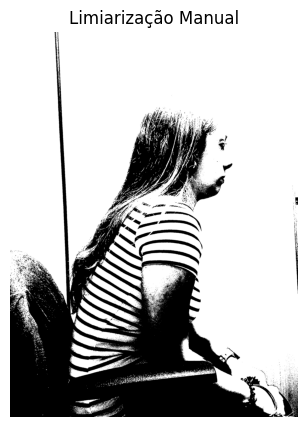

In [34]:
_, img2_manual_thresh = cv2.threshold(postura_gray, 80, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))
plt.imshow(img2_manual_thresh, cmap='gray')
plt.title(f'Limiarização Manual')
plt.axis('off')

plt.show()

# 3. Análise e discussão

5.a). No contexto da limiarização de imagens, o notebook apresenta a inspeção visual do histograma e os métodos automáticos como formas de escolher um limiar. Explique a diferença fundamental entre essas duas abordagens para a seleção do limiar T. Quais são as principais vantagens e desvantagens de cada método, considerando a precisão, a subjetividade e a aplicabilidade a diferentes tipos de imagens?

A principal diferença é que a inspeção visual do histograma é feita manualmente para um ser humano, e pode ser feita de forma precisa quando feito por um especialista. Além disso, a forma manual também posibilita uma maior subjetividade, já que depende da interpretação do usuário e não é escalável. Já os métodos automáticos não há margem para interpretação, já que é feita de forma automática, além disso, podemos fazer de forma escalável.




(5.b). Considerando a “img2” e seu histograma, discuta o impacto da escolha de
diferentes limiares. Explique por que um limiar muito baixo (“T=50”) ou muito alto (“T=125”) pode resultar em uma segmentação insatisfatória. Com base no histograma da “img2” , sugira um valor de limiar que você consideraria mais adequado para separar os objetos do fundo e justifique sua escolha.



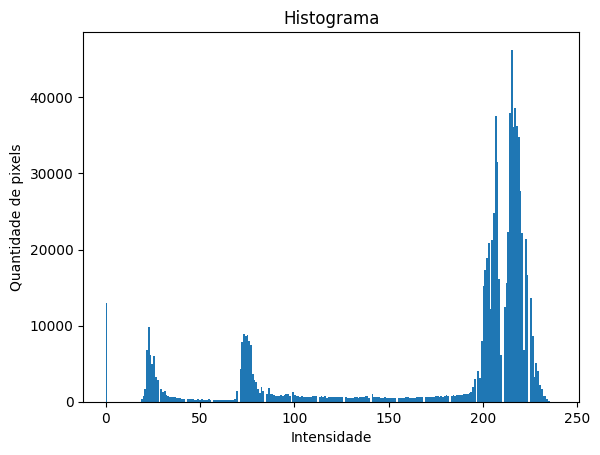

In [22]:
plt.hist(img2.ravel(), bins=256)
plt.title("Histograma")
plt.xlabel("Intensidade")
plt.ylabel("Quantidade de pixels")
plt.show()

Limeares muito baixos, o fundo é confundido com o objeto e há perda de contraste entre as regiões, enquanto um limear muito alto, parte do objeto se perde e objetos ficam incompletos. Um bom jeito de escolher um limear é entre os picos de min e max, nesse caso algo entre 120 e 140.

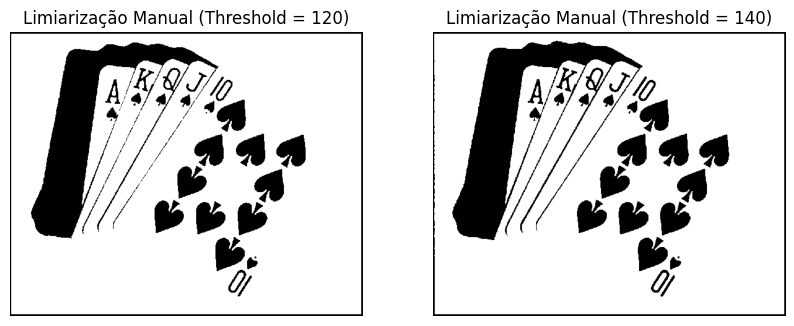

In [29]:
img2_gray = cv2.cvtColor(img2, cv2.COLOR_RGBA2GRAY)

_, img2_manual_thresh_120 = cv2.threshold(img2_gray, 120, 255, cv2.THRESH_BINARY)
_, img2_manual_thresh_140 = cv2.threshold(img2_gray, 140, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img2_manual_thresh_120, cmap='gray')
plt.title(f'Limiarização Manual (Threshold = {120})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2_manual_thresh_140, cmap='gray')
plt.title(f'Limiarização Manual (Threshold = {140})')
plt.axis('off')

plt.show()


(5.c). Com base na imagem “rice.png” (Exemplo 5) e nos resultados obtidos com o método de Otsu, qual a principal vantagem de utilizar um método automático como o de Otsu em comparação com a "tentativa e erro" para a segmentação de grãos de arroz neste tipo de imagem?
---



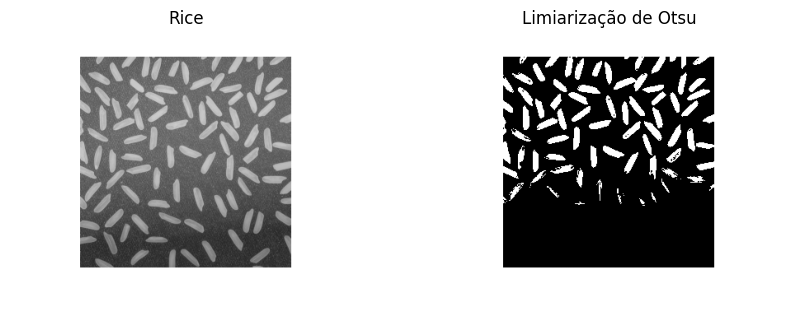

In [24]:
img_gray_rice = cv2.cvtColor(rice, cv2.COLOR_RGBA2GRAY)
_, img_otsu_thresh = cv2.threshold(img_gray_rice, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rice, cmap='gray')
plt.title('Rice')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_otsu_thresh, cmap='gray')
plt.title('Limiarização de Otsu')
plt.axis('off')

plt.show()

 Como é uma imagem simples, com objeto e fundo bem definido, por termos um fundo escuro e objeto claro, a limiarização de otsu define de forma quase ótima um limiar sem a ação humana de forma rápida e automática.

# 4. Conclusão